# Spectral Earth Dataset Wrapper Test

In [1]:
import sys
import os

os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)

Adding /home/ando to sys.path


In [3]:
from geofm_src.datasets.spectral_earth_wrapper import SpectralEarthDataset
from geofm_src.factory import create_dataset

# dataset = SpectralEarthDataset(root='/data/panopticon/datasets/spectral_earth', split='train', task_dir='corine')

# sample = dataset[0]



/home/ando/.conda/envs/fm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
sample, label = dataset[0]
sample.shape, label

(torch.Size([202, 128, 128]),
 tensor([0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0]))

## Test Channel Sampler

In [9]:
from omegaconf import OmegaConf
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('geofm_src/configs/dataset/corine_21b.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)
display(ds_cfg)

[ClsDataAugmentation: train] Sampling channels: [0, 15, 23, 30, 39, 52, 54, 69, 73, 81, 94, 107, 114, 123, 132, 142, 148, 154, 169, 175, 191]
[ClsDataAugmentation: val/test] Sampling channels: [0, 15, 23, 30, 39, 52, 54, 69, 73, 81, 94, 107, 114, 123, 132, 142, 148, 154, 169, 175, 191]


{'defaults': ['base_dataset'], 'dataset_type': 'corine', 'task': 'classification', 'dataset_name': 'spectral_earth', 'num_classes': 19, 'num_channels': 21, 'band_ids': [0, 15, 23, 30, 39, 52, 54, 69, 73, 81, 94, 107, 114, 123, 132, 142, 148, 154, 169, 175, 191], 'data_path': '${oc.env:DATASETS_DIR}/spectral_earth', 'image_resolution': 128, 'multilabel': True, 'senpamae_srf_name': 'rfs_enmap_recon.npy', 'senpamae_channels': [0, 15, 23, 30, 39, 52, 54, 69, 73, 81, 94, 107, 114, 123, 132, 142, 148, 154, 169, 175, 191], 'band_gsds': [30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30], 'wavelengths_mean_nm': [418, 491, 530, 566, 616, 699, 713, 824, 855, 911, 968, 1070, 1151, 1258, 1597, 1706, 2005, 2059, 2191, 2241, 2369], 'wavelengths_mean_microns': [0.418, 0.491, 0.53, 0.566, 0.616, 0.699, 0.713, 0.824, 0.855, 0.911, 0.968, 1.07, 1.151, 1.258, 1.597, 1.706, 2.005, 2.059, 2.191, 2.241, 2.369], 'wavelengths_sigma_nm': [2, 2, 2, 2, 3, 3, 3, 3, 4, 3, 4, 4, 4, 

In [54]:
sample, label = train_ds[11]
sample.shape, label

(torch.Size([21, 224, 224]),
 tensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]))

torch.Size([21, 224, 224]) tensor([1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])
tensor(-1.2093) tensor(5.4322)


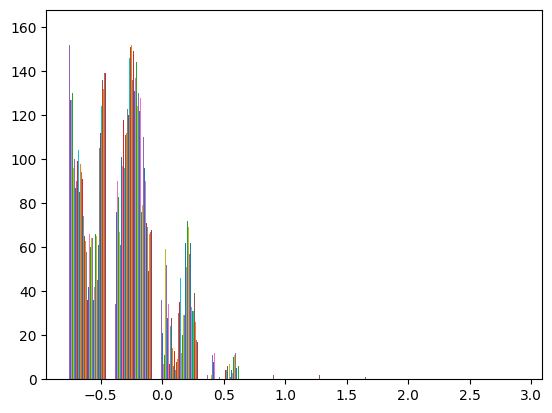

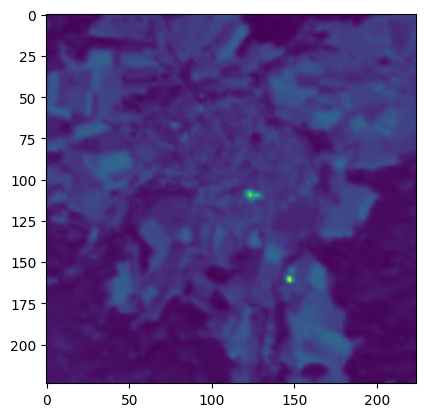

In [58]:
import random
import matplotlib.pyplot as plt
sample, label = train_ds[random.randint(0, len(train_ds))]
print(sample.shape, label)
print(sample.min(), sample.max())

plt.hist(sample[5], bins=10)
plt.show()

plt.imshow(sample[5])
plt.show()


In [36]:
sample, label = test_ds[-1]
sample.shape, label

(torch.Size([21, 224, 224]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]))

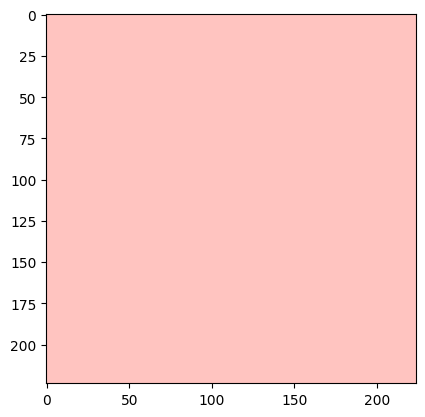

In [37]:
rgb = sample[[5,8,10], :, :]


import matplotlib.pyplot as plt

img = rgb.permute(1, 2, 0).numpy()

img = img - img.min() / (img.max() - img.min())

plt.imshow(img)
plt.show()



# Test channel simulator


Lets use Corine data as input and map it to the Planet SuperDove sensor

In [31]:
import matplotlib.pyplot as plt

def plot_superdove_sensor(sample):

    rgb = sample[[5,3,1], :, :]

    img = rgb.permute(1, 2, 0).numpy()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.show()

In [15]:
from omegaconf import OmegaConf
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('src/configs/dataset/corine_sd.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)

[ClsDataAugmentation: train] Simulating channels: tensor([[443,   7],
        [490,  20],
        [532,  14],
        [565,  15],
        [611,   9],
        [665,  12],
        [706,   6],
        [864,  15]])
[ClsDataAugmentation: val/test] Simulating channels: tensor([[443,   7],
        [490,  20],
        [532,  14],
        [565,  15],
        [611,   9],
        [665,  12],
        [706,   6],
        [864,  15]])


torch.Size([8, 224, 224]) tensor([0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])


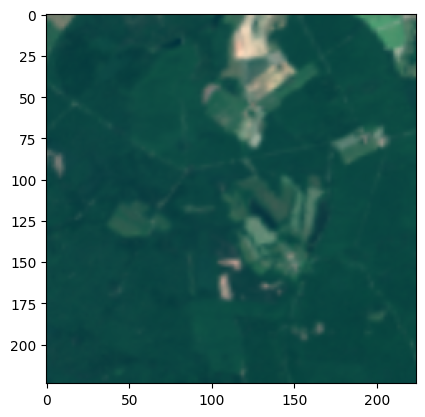

In [40]:
import random
i = random.randint(0, len(train_ds))
sample, label = train_ds[i]
print(sample.shape, label)
plot_superdove_sensor(sample)

torch.Size([8, 224, 224]) tensor([0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])


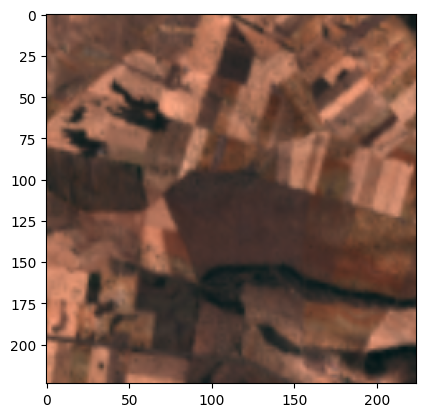

In [39]:
i = random.randint(0, len(val_ds))
sample, label = val_ds[i]
print(sample.shape, label)
plot_superdove_sensor(sample)

torch.Size([8, 224, 224]) tensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0])


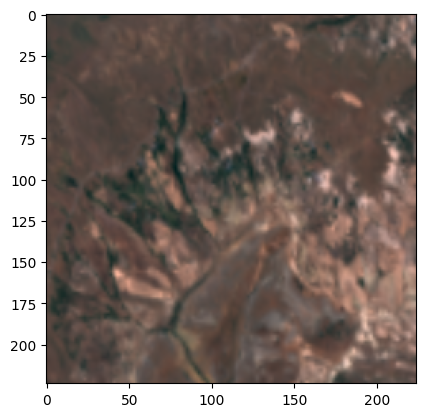

In [38]:
i = random.randint(0, len(test_ds))
sample, label = test_ds[i]
print(sample.shape, label)
plot_superdove_sensor(sample)


In [41]:
ds_cfg

{'defaults': ['base_dataset'], 'dataset_type': 'corine', 'task': 'classification', 'dataset_name': 'spectral_earth', 'num_classes': 19, 'num_channels': 8, 'data_path': '${oc.env:DATASETS_DIR}/spectral_earth', 'image_resolution': 224, 'multilabel': True, 'full_spectra': True, 'target_dataset_name': 'dummy-superdove', 'wavelengths_mean_nm': [443, 490, 532, 565, 611, 665, 706, 864], 'wavelengths_sigma_nm': [7, 20, 14, 15, 9, 12, 6, 15]}